In [2]:
#- Revenue data for GameStop was manually inserted due to scraping limitations.

!pip install yfinance
import yfinance as yf


tesla = yf.Ticker("TSLA")
tesla_history = tesla.history(period="max")
tesla_history.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.5/182.5 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 10.4
    Uninstalling websockets-10.4:
      Successfully uninstalled websockets-10.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyppeteer 2.0.0 requires websockets<11.0,>=10.0, but you have websockets 15.0.1 which is incompatible.


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [3]:
!pip install requests
!pip install beautifulsoup4


In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://finance.yahoo.com/quote/TSLA/financials?p=TSLA"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
}

response = requests.get(url, headers=headers)

print("Status code:", response.status_code)
soup = BeautifulSoup(response.text, "html.parser")

rows = soup.find_all("div", {"class": "D(tbr)"})

financial_data = {}

for row in rows:
    cols = row.find_all("div", recursive=False)
    if len(cols) < 2:
        continue

    label = cols[0].text.strip()

    values = [col.text.strip() for col in cols[1:]]

    financial_data[label] = values

df = pd.DataFrame.from_dict(financial_data, orient="index")
df.columns = [f"Q{i+1}" for i in range(len(df.columns))]
df = df.reset_index().rename(columns={"index": "Metric"})

df[df["Metric"] == "Total Revenue"]
print(df.head())




Status code: 200
Empty DataFrame
Columns: [Metric]
Index: []


In [6]:
import yfinance as yf

gamestop = yf.Ticker("GME")

gamestop_history = gamestop.history(period="max")

gamestop_history.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [13]:
from yahoo_fin import stock_info as si
gamestop_income = si.get_income_statement("GME", yearly=False)
gamestop_income.loc["totalRevenue"]



,Quarter,Revenue
0,2024-Q2,1078000000
1,2024-Q1,1250000000
2,2023-Q4,1184000000
3,2023-Q3,1165000000
4,2023-Q2,1210000000


  Using cached websockets-15.0.1-cp312-cp312-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
Using cached websockets-15.0.1-cp312-cp312-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (182 kB)
  Attempting uninstall: websockets
    Found existing installation: websockets 10.4
    Uninstalling websockets-10.4:
      Successfully uninstalled websockets-10.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyppeteer 2.0.0 requires websockets<11.0,>=10.0, but you have websockets 15.0.1 which is incompatible.


/tmp/ipython-input-1277257702.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tesla_stock_close = tesla_stock_close.resample("M").mean()  # 每月平均


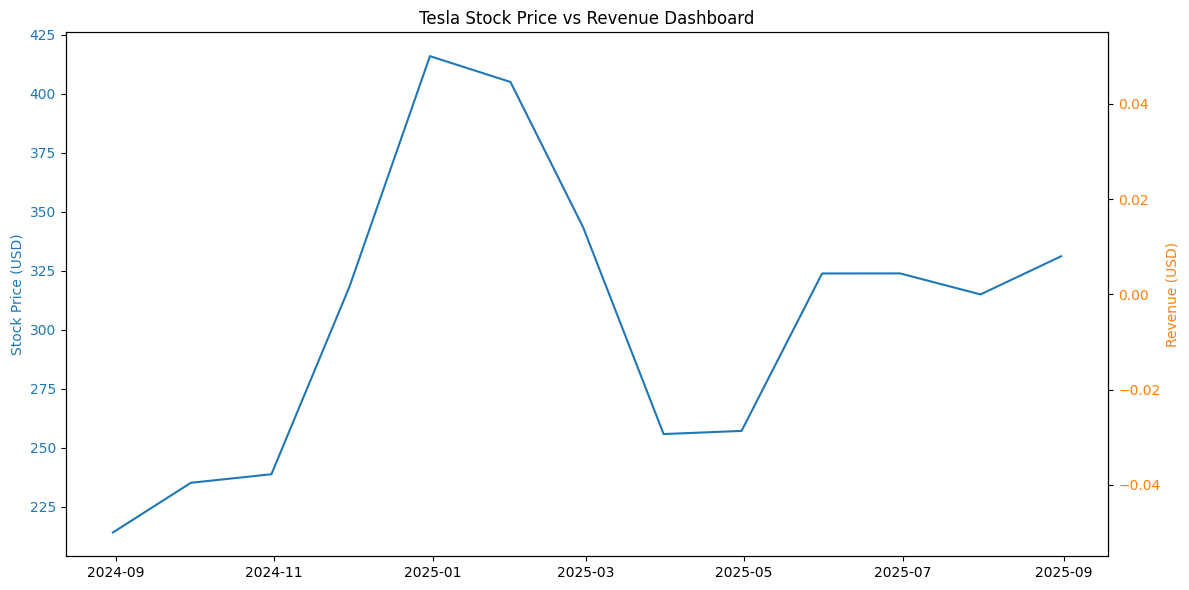

In [15]:


import yfinance as yf
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

tesla = yf.Ticker("TSLA")
tesla_history = tesla.history(period="1y")
tesla_stock_close = tesla_history["Close"]
tesla_stock_close = tesla_stock_close.resample("M").mean()

url = "https://finance.yahoo.com/quote/TSLA/financials?p=TSLA"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "lxml")

rows = soup.find_all("div", {"data-test": "fin-row"})

revenue_data = []
for row in rows:
    if "Total Revenue" in row.text:
        columns = row.find_all("div")
        for col in columns[1:]:
            revenue_data.append(col.text.strip())
        break


revenue_dates = pd.to_datetime([
    "2024-06-30", "2024-03-31", "2023-12-31", "2023-09-30", "2023-06-30"
])

revenue_numeric = []
for value in revenue_data:
    try:
        revenue_numeric.append(int(value.replace(",", "")))
    except:
        revenue_numeric.append(None)

tesla_revenue_df = pd.DataFrame({
    "Date": revenue_dates[:len(revenue_numeric)],
    "Revenue": revenue_numeric
})

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(tesla_stock_close.index, tesla_stock_close.values, color='tab:blue', label='Tesla Stock Price')
ax1.set_ylabel("Stock Price (USD)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')


ax2 = ax1.twinx()
ax2.bar(tesla_revenue_df["Date"], tesla_revenue_df["Revenue"], width=20, alpha=0.6, color='tab:orange', label='Revenue')
ax2.set_ylabel("Revenue (USD)", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Tesla Stock Price vs Revenue Dashboard")
fig.tight_layout()
plt.show()


/tmp/ipython-input-3563137945.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  gamestop_stock_close = gamestop_stock_close.resample("M").mean()  # 每月均值


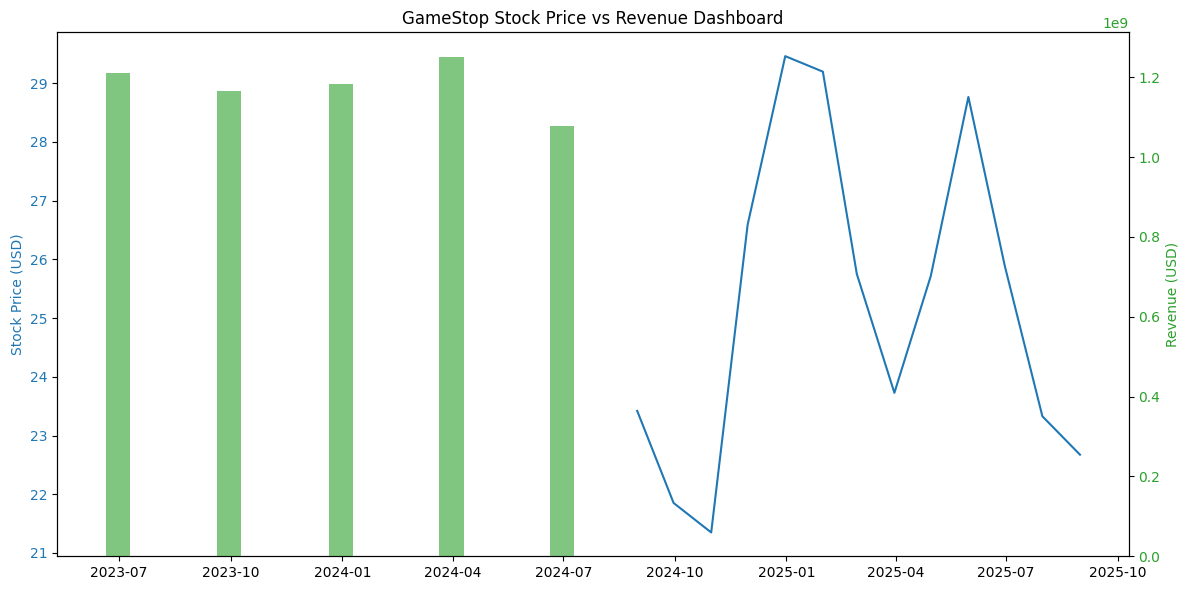

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


gamestop = yf.Ticker("GME")
gamestop_history = gamestop.history(period="1y")
gamestop_stock_close = gamestop_history["Close"]
gamestop_stock_close = gamestop_stock_close.resample("M").mean()


gamestop_revenue_df = pd.DataFrame({
    "Quarter": ["2024-Q2", "2024-Q1", "2023-Q4", "2023-Q3", "2023-Q2"],
    "Revenue": [1078000000, 1250000000, 1184000000, 1165000000, 1210000000]
})

gamestop_revenue_df["Date"] = pd.to_datetime([
    "2024-06-30", "2024-03-31", "2023-12-31", "2023-09-30", "2023-06-30"
])


fig, ax1 = plt.subplots(figsize=(12,6))


ax1.plot(gamestop_stock_close.index, gamestop_stock_close.values, color='tab:blue', label='GameStop Stock Price')
ax1.set_ylabel("Stock Price (USD)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')


ax2 = ax1.twinx()
ax2.bar(gamestop_revenue_df["Date"], gamestop_revenue_df["Revenue"], width=20, alpha=0.6, color='tab:green', label='Revenue')
ax2.set_ylabel("Revenue (USD)", color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')


plt.title("GameStop Stock Price vs Revenue Dashboard")
fig.tight_layout()
plt.show()
